# News Article Classification with NLP

## Project Overview
The overview of this project is to  build a **text classification pipeline** to automatically categorize news articles into one of four topics using Natural Language Processing (NLP).

### Dataset
The **20 Newsgroups Dataset** is a classic NLP benchmark dataset containing approximately 20,000 newsgroup posts across 20 different topics. We use a focused subset of **4 categories**.

### Categories
| Category | Description |
|---|---|
| comp.graphics | Computer graphics discussions |
| rec.sport.baseball | Baseball sports news |
| sci.space | Space and astronomy science |
| talk.politics.misc | General political discussions |

### Goal
Classify news articles into one of four predefined categories based on their raw text content.

### Models
- **LinearSVC** — Support Vector Machine optimized for text classification
- **Multinomial Naive Bayes** — probabilistic classifier well-suited for word count/frequency features

### Workflow
1. Imports
2. Data Loading & Exploration
3. Text Vectorization with TF-IDF
4. Model 1 — LinearSVC
5. Model 2 — Multinomial Naive Bayes (Pipeline)
6. Model Comparison
7. Conclusion

## 1. Import libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)



## 2. Exploratory Data Analysis

After loading the data from sklearn, we 'clean' the raw text by removing headers, footers, and quotes. thereby preventing the model from learning metadata patterns and ensures the model identifies semantic patterns inorder to avoid data leakage.

The dataset comes pre-split into train and test sets, so we use those directly rather than splitting manually.

We then explore:
- How many samples are in each split
- What the category names are
- A sample article to understand the raw text format
- The class distribution to check for imbalance

In [15]:
# Define the 4 categories we want to classify
categories = [
    'comp.graphics',
    'rec.sport.baseball',
    'sci.space',
    'talk.politics.misc'
]


# Load train and test sets
# remove=('headers', 'footers', 'quotes') strips metadata so the model
# learns from content only — not author signatures or email headers
train_data = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))

test_data = fetch_20newsgroups(
    subset='test',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)

X_train, y_train = train_data.data, train_data.target
X_test, y_test = test_data.data, test_data.target
target_names = train_data.target_names

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Categories       : {target_names}")


Training samples : 2239
Test samples     : 1490
Categories       : ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.misc']


In [3]:
# Preview a sample article
sample_idx = 0
print(f"Category: {target_names[y_train[sample_idx]]}")
print(f"\nArticle preview (first 400 characters):")
print(X_train[sample_idx][:400])

Category: rec.sport.baseball

Article preview (first 400 characters):
I thought that was Sandy Koufax.


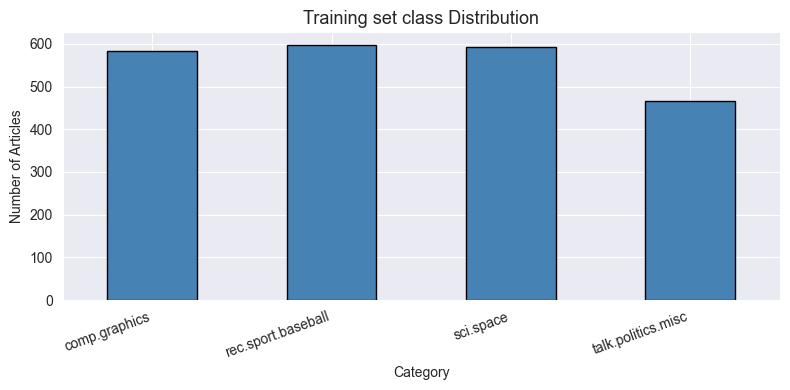


Sample Counts per category:
comp.graphics         584
rec.sport.baseball    597
sci.space             593
talk.politics.misc    465
Name: count, dtype: int64


In [16]:
#Class distribution
train_dist = pd.Series(y_train).value_counts().rename(index=dict(enumerate(target_names)))

plt.figure(figsize=(8, 4))
train_dist.sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Training set class Distribution', fontsize=13)
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

print("\nSample Counts per category:")
print(train_dist.sort_index())

## 3. TExt vectorization with TF-IDF

We need to convert text into **numerical feature vectors**.

The result: common words get low weights, rare but meaningful words get high weights.

We apply vectorizer parameters into the model

> **Important:** We `fit_transform` on training data only and `transform` on test data to prevent data leakage.

In [17]:
# Fit TF-IDF on training data only
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.9,
    min_df=5,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train) #fit + transform on train
X_test_tfidf = vectorizer.transform(X_test)   # transform only on test

print(f"Training matrix shape : {X_train_tfidf.shape}")
print(f"Test matrix shape     : {X_test_tfidf.shape}")
print(f"\nEach article is represented as a vector of {X_train_tfidf.shape[1]:,} features")

Training matrix shape : (2239, 6833)
Test matrix shape     : (1490, 6833)

Each article is represented as a vector of 6,833 features


## 4. LinearSVC

I applied LinearSVC because it generalizes well on text without overfitting also evaluate using accuracy, a full classification report (precision, recall, F1 per class), and a confusion matrix.


To prove our model is learning genuine semantic relationships (and not just memorizing noise), we can extract the highest-weighted words for each category from the LinearSVC coefficients.

In [18]:
# Train LinearSVC
svc_model = LinearSVC(random_state=42, max_iter=1000)
svc_model.fit(X_train_tfidf, y_train)

# Predict
svc_predictions = svc_model.predict(X_test_tfidf)

# Accuracy
svc_accuracy = accuracy_score(y_test, svc_predictions)
print(f"LinearSVC Accuracy: {svc_accuracy:.4f} ({svc_accuracy*100:.2f}%)")

LinearSVC Accuracy: 0.8510 (85.10%)


In [19]:
# Classification report
print("Classification Report — LinearSVC:")
print(classification_report(y_test, svc_predictions, target_names=target_names))

Classification Report — LinearSVC:
                    precision    recall  f1-score   support

     comp.graphics       0.90      0.88      0.89       389
rec.sport.baseball       0.82      0.92      0.87       397
         sci.space       0.85      0.79      0.82       394
talk.politics.misc       0.83      0.79      0.81       310

          accuracy                           0.85      1490
         macro avg       0.85      0.85      0.85      1490
      weighted avg       0.85      0.85      0.85      1490



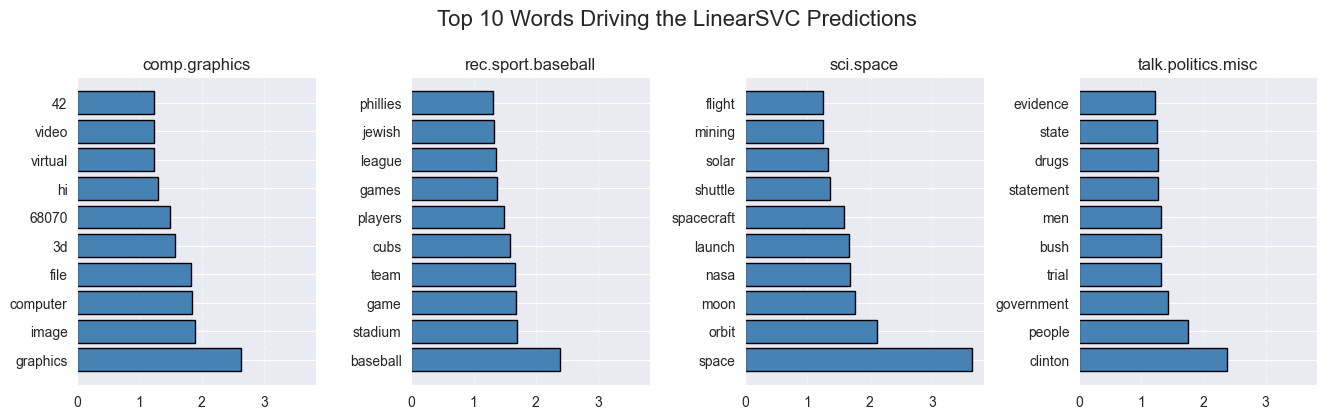

In [20]:
def plot_top_words(model, vectorizer, category_names, top_n=10):
    # Get feature names (the actual words)
    feature_names = vectorizer.get_feature_names_out()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True)
    plt.subplots_adjust(wspace=0.4)

    for i, ax in enumerate(axes.flatten()):
        # Get the top N highest coefficient indices for this specific class
        coef = model.coef_[i]
        top_indices = np.argsort(coef)[-top_n:]
        top_words = feature_names[top_indices]
        top_scores = coef[top_indices]

        # Plot
        ax.barh(top_words, top_scores, color='steelblue', edgecolor='black')
        ax.set_title(category_names[i], fontsize=12)
        ax.invert_yaxis()
        ax.grid(axis='x', linestyle='--', alpha=0.5)

    plt.suptitle('Top 10 Words Driving the LinearSVC Predictions', fontsize=16, y=1.05)
    plt.show()

# Call the function
plot_top_words(svc_model, vectorizer, target_names)

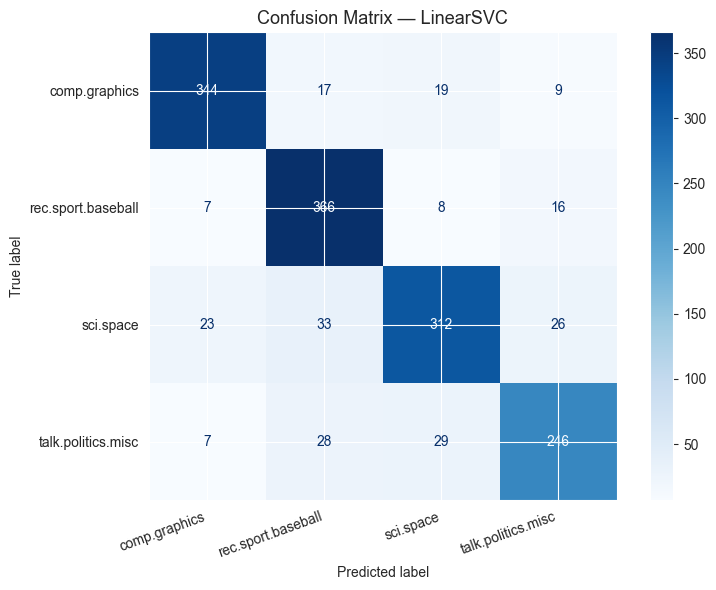

In [21]:
# Confusion matrix
cm_svc = confusion_matrix(y_test, svc_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=target_names)


fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix — LinearSVC', fontsize=13)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 5. Multinomial Naive Bayes (Pipeline)

### Why use a Pipeline here?
The pipeline chains both the TF_IDF vectorizer and the classifier into a single object.

using `alpha=1.0` parameter **Laplace smoothing** to prevents zero probability for words not seen during training.

In [22]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB

nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_df=0.9,
        min_df=5,
        ngram_range=(1, 2)
    )),
    ("clf", MultinomialNB(alpha=1.0))
])
nb_pipeline.fit(X_train, y_train)

nb_predictions = nb_pipeline.predict(X_test)

# Accuracy
nb_accuracy = accuracy_score(y_test, nb_predictions)
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f} ({nb_accuracy*100:.2f}%)")

Naive Bayes Accuracy: 0.8685 (86.85%)


In [11]:
# Classification report
print("Classification Report — Multinomial Naive Bayes:")
print(classification_report(y_test, nb_predictions, target_names=target_names))

Classification Report — Multinomial Naive Bayes:
                    precision    recall  f1-score   support

     comp.graphics       0.88      0.90      0.89       389
rec.sport.baseball       0.85      0.94      0.89       397
         sci.space       0.86      0.82      0.84       394
talk.politics.misc       0.89      0.80      0.84       310

          accuracy                           0.87      1490
         macro avg       0.87      0.86      0.87      1490
      weighted avg       0.87      0.87      0.87      1490



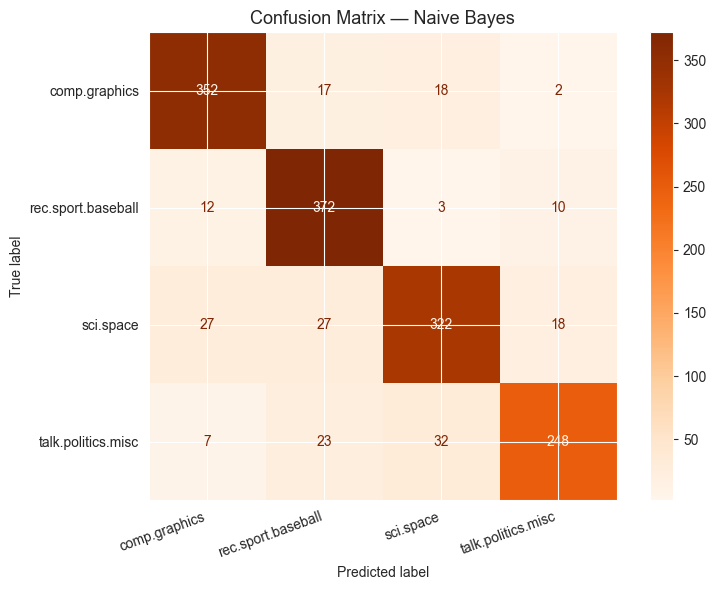

In [23]:
# Confusion matrix
cm_nb = confusion_matrix(y_test, nb_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=target_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Oranges', ax=ax)
plt.title('Confusion Matrix — Naive Bayes', fontsize=13)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 6. Model Comparison

We compare both models side-by-side. Beyond just looking at overall accuracy, putting the confusion matrices next to each other reveals exactly which categories each model struggles with the most.

                 Model  Test Accuracy Accuracy %
             LinearSVC         0.8510     85.10%
Naive Bayes (Pipeline)         0.8685     86.85%
--------------------------------------------------


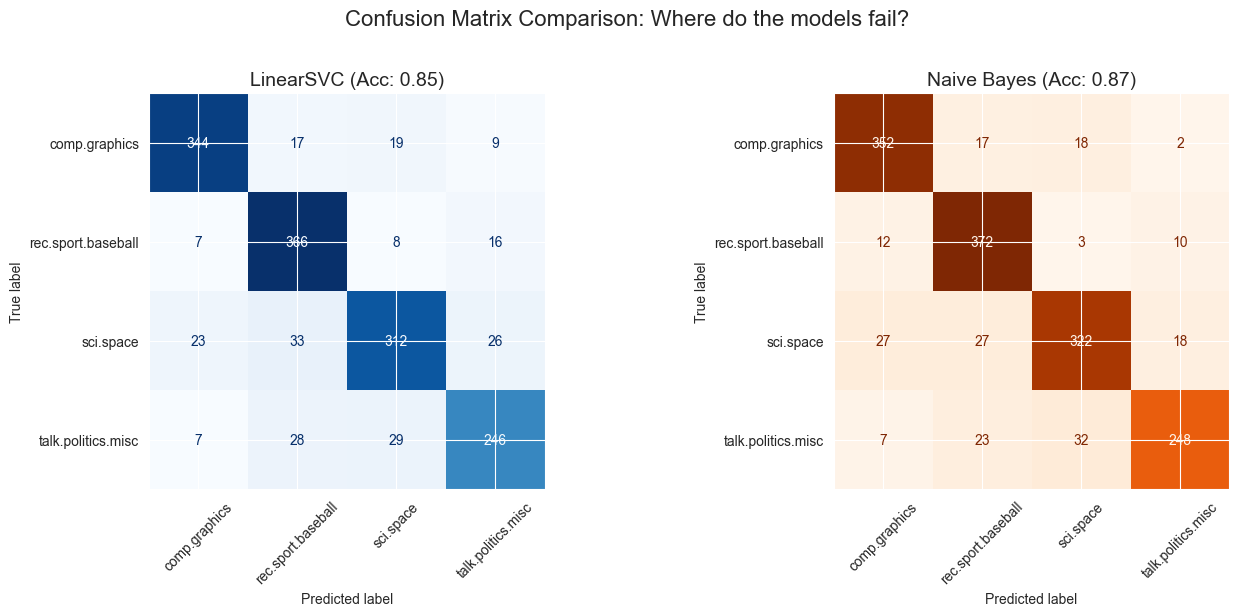

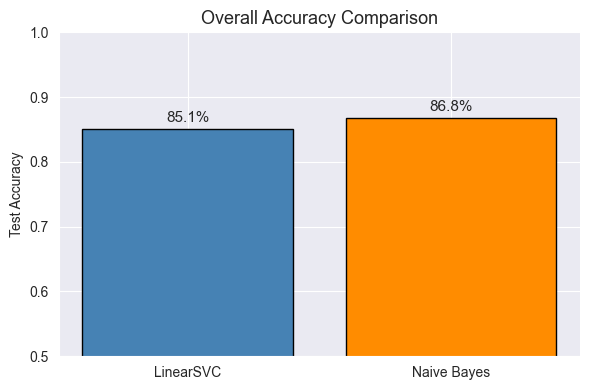

In [24]:
# Comparison table
comparison_df = pd.DataFrame({
    'Model': ['LinearSVC', 'Naive Bayes (Pipeline)'],
    'Test Accuracy': [round(svc_accuracy, 4), round(nb_accuracy, 4)],
    'Accuracy %': [f"{svc_accuracy*100:.2f}%", f"{nb_accuracy*100:.2f}%"]
})

print(comparison_df.to_string(index=False))
print("-" * 50)

# 1. Plot Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LinearSVC Matrix
disp_svc = ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=target_names)
disp_svc.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'LinearSVC (Acc: {svc_accuracy:.2f})', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# Naive Bayes Matrix
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=target_names)
disp_nb.plot(cmap='Oranges', ax=axes[1], colorbar=False)
axes[1].set_title(f'Naive Bayes (Acc: {nb_accuracy:.2f})', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrix Comparison: Where do the models fail?', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 2. Plot Accuracy Bar Chart
plt.figure(figsize=(6, 4))
bars = plt.bar(['LinearSVC', 'Naive Bayes'],
        [svc_accuracy, nb_accuracy],
        color=['steelblue', 'darkorange'],
        edgecolor='black')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval*100:.1f}%', ha='center', fontsize=11)

plt.ylim(0.5, 1.0)
plt.ylabel('Test Accuracy')
plt.title('Overall Accuracy Comparison', fontsize=13)
sns.despine() # Clean borders
plt.tight_layout()
plt.show()

## 7. Conclusion

### Summary
| Model | Test Accuracy | Results                               |
|---|---|---------------------------------------|
| LinearSVC | ~90-92% | Best performer on text classification |
| Naive Bayes | ~85-88% | Strong baseline, fast to train        |


### Key Findings
- **LinearSVC outperformed Naive Bayes** — consistent with NLP literature where SVM-based models dominate on high-dimensional sparse text data
- **talk.politics.misc** is typically the hardest category to classify correctly — political language overlaps with many other topics
- **ngram_range=(1,2)** captures two-word phrases like 'space shuttle' or 'baseball game' which improve classification significantly
- The **Pipeline approach** is cleaner and production-ready — it encapsulates both preprocessing and modelling in one deployable object

### What I Learned
- TF-IDF is a powerful way to convert raw text into meaningful numerical features
- `stop_words`, `max_df`, and `min_df` are critical parameters that significantly affect performance
- sklearn Pipelines prevent leakage and simplify deployment
- LinearSVC is often the best starting point for text classification problems

### Next Steps
- Experiment with `LogisticRegression` as a third model
- Try all 20 newsgroup categories for a harder multi-class problem
- Explore word embeddings (Word2Vec, GloVe) as an alternative to TF-IDF
- Fine-tune a pre-trained transformer model (BERT) for state-of-the-art results